# Senior Citizen Identification Model

## Project Objective

The objective of this project is to develop a machine learning system that detects multiple persons from a video or real-time webcam feed and predicts their age and gender.

The system identifies people aged more than 60 as **Senior Citizens** and detects their gender. It also records their age, gender, and time of visit in a CSV/Excel file.

## Features

- Age Prediction using CNN
- Gender Classification using CNN
- Multiple Person/Face Detection
- Senior Citizen Identification
- Real-time Webcam/Video Processing
- CSV/Excel Data Logging
- Gradio GUI Interface
- Model Evaluation and Visualizations

## Problem Statement

The task is to detect multiple people from a video or webcam feed and predict their age and gender.

### Required Logic

1. Detect multiple faces/persons.
2. Predict age and gender using CNN models.
3. If **age > 60**, mark the person as **Senior Citizen** and display their gender.
4. If **age ≤ 60**, display their normal age and gender.
5. Store the **age, gender, and time of visit** in CSV/Excel format.

## Dataset Description

### Age, Gender and Ethnicity (Face Data) Dataset
This project uses the **Age, Gender and Ethnicity (Face Data)** dataset.
The dataset contains:
- Age
- Gender
- Ethnicity
- Facial image pixel values
The images are processed into **48 × 48 grayscale images** before being used for CNN training.

In [1]:
!pip install -q gradio openpyxl

In [2]:
import os, glob, time
from datetime import datetime, timedelta

import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import tensorflow as tf
import gradio as gr

from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, f1_score, precision_score, recall_score,
                              mean_absolute_error, r2_score, confusion_matrix, ConfusionMatrixDisplay)

np.random.seed(42)
tf.random.set_seed(42)

IMG_SIZE = 48                # matches the dataset's native face crop size, no need to resize up
SENIOR_AGE_THRESHOLD = 60    # age > 60 = senior citizen

OUTPUT_DIR = "/kaggle/working" if os.path.isdir("/kaggle/working") else "."
CSV_PATH = os.path.join(OUTPUT_DIR, "visit_log.csv")
XLSX_PATH = os.path.join(OUTPUT_DIR, "visit_log.xlsx")
os.makedirs(OUTPUT_DIR, exist_ok=True)
print("writing outputs to", OUTPUT_DIR)

total_visits_logged = 0  # bumped by 1 every time log_visit() actually writes a row

writing outputs to /kaggle/working


## Step 1 - load the dataset

In [3]:
candidates = glob.glob("/kaggle/input/**/age_gender.csv", recursive=True)
DATA_CSV = candidates[0] if candidates else "age_gender.csv"

if not os.path.exists(DATA_CSV):
    raise FileNotFoundError(
        "can't find age_gender.csv - add the 'Age, Gender and Ethnicity (Face Data) CSV' "
        "dataset (Add Input, right sidebar) then Run All again"
    )

print("loading:", DATA_CSV)
df = pd.read_csv(DATA_CSV)
print(df.shape)
df.head()

loading: /kaggle/input/datasets/nipunarora8/age-gender-and-ethnicity-face-data-csv/age_gender.csv
(23705, 5)


,age,ethnicity,gender,img_name,pixels
0,1,2,0,20161219203650636.jpg.chip.jpg,129 128 128 126 127 130 133 135 139 142 145 14...
1,1,2,0,20161219222752047.jpg.chip.jpg,164 74 111 168 169 171 175 182 184 188 193 199...
2,1,2,0,20161219222832191.jpg.chip.jpg,67 70 71 70 69 67 70 79 90 103 116 132 145 155...
3,1,2,0,20161220144911423.jpg.chip.jpg,193 197 198 200 199 200 202 203 204 205 208 21...
4,1,2,0,20161220144914327.jpg.chip.jpg,202 205 209 210 209 209 210 211 212 214 218 21...


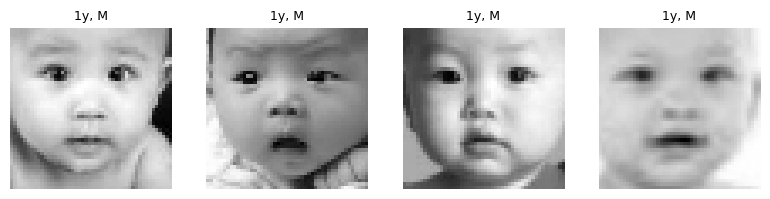

In [4]:
def row_to_face(pixels_str, side=IMG_SIZE):
    arr = np.fromstring(pixels_str, dtype=np.uint8, sep=" ")
    img_side = int(round(arr.size ** 0.5))
    img = arr.reshape(img_side, img_side)
    if img_side != side:
        img = cv2.resize(img, (side, side))
    return img

# quick sanity check on a couple of rows before doing the whole dataset
plt.figure(figsize=(8, 2))
for i in range(4):
    row = df.iloc[i]
    plt.subplot(1, 4, i + 1)
    plt.imshow(row_to_face(row["pixels"]), cmap="gray")
    plt.title(f'{int(row["age"])}y, {"M" if row["gender"]==0 else "F"}', fontsize=9)
    plt.axis("off")
plt.tight_layout()
plt.show()

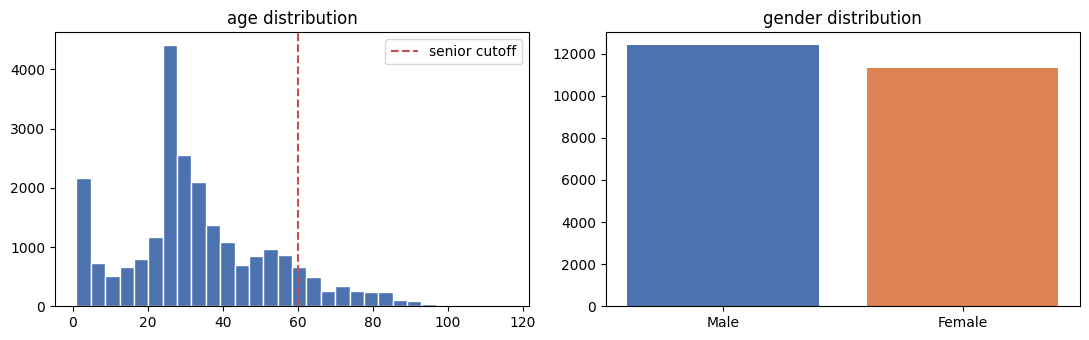

2395 / 23705 rows are seniors (age > 60)


In [5]:
# quick look at the label spread, same as the earlier version of this project
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].hist(df["age"], bins=30, color="#4C72B0", edgecolor="white")
axes[0].axvline(SENIOR_AGE_THRESHOLD, color="#C44E52", linestyle="--", label="senior cutoff")
axes[0].set_title("age distribution"); axes[0].legend()

gender_counts = df["gender"].map({0: "Male", 1: "Female"}).value_counts()
axes[1].bar(gender_counts.index, gender_counts.values, color=["#4C72B0", "#DD8452"])
axes[1].set_title("gender distribution")
plt.tight_layout()
plt.show()

print((df["age"] > SENIOR_AGE_THRESHOLD).sum(), "/", len(df), "rows are seniors (age > 60)")

## Step 2 - turn the dataframe into arrays the CNN can eat

In [6]:
MAX_ROWS = 15000  # cap it a bit so training doesn't take forever, bump this up if you have time

work_df = df.sample(n=min(MAX_ROWS, len(df)), random_state=42) if MAX_ROWS else df

X = np.stack([row_to_face(p) for p in work_df["pixels"]]).astype("float32")
X = X.reshape(-1, IMG_SIZE, IMG_SIZE, 1) / 255.0   # normalize 0-1, CNN likes that better than 0-255

y_gender = work_df["gender"].values.astype("float32")   # 0 = male, 1 = female
y_age = work_df["age"].values.astype("float32")

print("X:", X.shape, " gender:", y_gender.shape, " age:", y_age.shape)

X: (15000, 48, 48, 1)  gender: (15000,)  age: (15000,)


In [7]:
X_train, X_test, gender_train, gender_test, age_train, age_test = train_test_split(
    X, y_gender, y_age, test_size=0.15, random_state=42, stratify=y_gender
)
print("train:", len(X_train), " test:", len(X_test))

train: 12750  test: 2250


## Step 3 - the model itself

One CNN backbone (this is the "own model" part -- built and trained from scratch, no pretrained
weights anywhere), with two output heads coming off the same shared features:
- `gender_output` - sigmoid, male vs female
- `age_output` - plain number, no activation, since it's a regression not a classification

Sharing the backbone like this is basically free extra data for both tasks since the same
convolution filters get to learn from every image regardless of which label they're being scored
on.

In [8]:
inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 1))

x = tf.keras.layers.Conv2D(32, 3, activation="relu")(inputs)
x = tf.keras.layers.MaxPooling2D()(x)
x = tf.keras.layers.Conv2D(64, 3, activation="relu")(x)
x = tf.keras.layers.MaxPooling2D()(x)
x = tf.keras.layers.Conv2D(128, 3, activation="relu")(x)
x = tf.keras.layers.MaxPooling2D()(x)
x = tf.keras.layers.Flatten()(x)

shared = tf.keras.layers.Dense(128, activation="relu")(x)
shared = tf.keras.layers.Dropout(0.3)(shared)

gender_output = tf.keras.layers.Dense(1, activation="sigmoid", name="gender_output")(shared)
age_output = tf.keras.layers.Dense(1, name="age_output")(shared)   # no activation, just a number

model = tf.keras.Model(inputs=inputs, outputs=[gender_output, age_output])

model.compile(
    optimizer="adam",
    loss={"gender_output": "binary_crossentropy", "age_output": "mse"},
    loss_weights={"gender_output": 1.0, "age_output": 0.01},  # age loss (mse of years) is on a much
                                                                # bigger scale than bce, so it needs
                                                                # to be scaled down or it dominates
    metrics={"gender_output": "accuracy", "age_output": "mae"},
)
model.summary()

I0000 00:00:1788259253.427250      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1788259253.430177      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 48, 48, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 46, 46,    │        320 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 23, 23,    │          0 │ conv2d[0][0]      │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 21, 21,    │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 10, 10,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 8, 8, 128) │     73,856 │ max_pooling2d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 4, 4, 128) │          0 │ conv2d_2[0][0]    │
│ (MaxPooling2D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 2048)      │          0 │ max_pooling2d_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │    262,272 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gender_output       │ (None, 1)         │        129 │ dropout[0][0]     │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ age_output (Dense)  │ (None, 1)         │        129 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 355,202 (1.35 MB)

 Trainable params: 355,202 (1.35 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
history = model.fit(
    X_train,
    {"gender_output": gender_train, "age_output": age_train},
    validation_data=(X_test, {"gender_output": gender_test, "age_output": age_test}),
    epochs=20,
    batch_size=64,
)

Epoch 1/20
 28/200 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - age_output_loss: 1041.1775 - age_output_mae: 26.2205 - gender_output_accuracy: 0.5551 - gender_output_loss: 0.9340 - loss: 11.3458

I0000 00:00:1788259260.804294      74 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


200/200 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - age_output_loss: 475.4815 - age_output_mae: 16.7524 - gender_output_accuracy: 0.5180 - gender_output_loss: 0.9157 - loss: 5.6739 - val_age_output_loss: 365.5466 - val_age_output_mae: 15.6976 - val_gender_output_accuracy: 0.6213 - val_gender_output_loss: 0.6506 - val_loss: 4.3563
Epoch 2/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - age_output_loss: 335.8228 - age_output_mae: 14.1118 - gender_output_accuracy: 0.6646 - gender_output_loss: 0.6206 - loss: 3.9871 - val_age_output_loss: 252.8386 - val_age_output_mae: 11.8602 - val_gender_output_accuracy: 0.7284 - val_gender_output_loss: 0.5295 - val_loss: 3.0841
Epoch 3/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - age_output_loss: 258.2048 - age_output_mae: 12.3474 - gender_output_accuracy: 0.7321 - gender_output_loss: 0.5507 - loss: 3.1383 - val_age_output_loss: 234.0210 - val_age_output_mae: 11.2570 - val_gender_output_accuracy: 0.7422 - val_gender_output_loss: 0.5075 - val_loss: 2.8702
Epoch 4

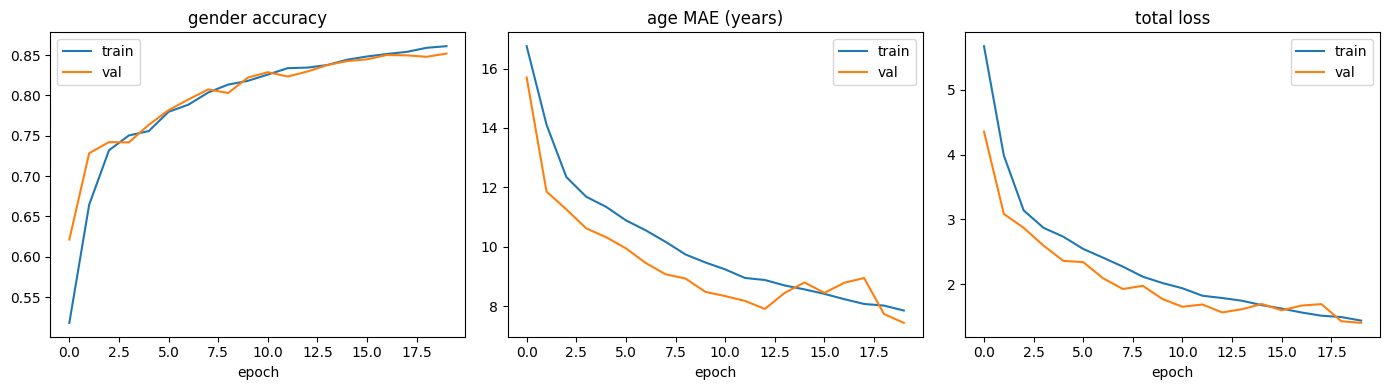

In [10]:
plt.figure(figsize=(14, 4))

plt.subplot(1, 3, 1)
plt.plot(history.history["gender_output_accuracy"], label="train")
plt.plot(history.history["val_gender_output_accuracy"], label="val")
plt.title("gender accuracy"); plt.xlabel("epoch"); plt.legend()

plt.subplot(1, 3, 2)
plt.plot(history.history["age_output_mae"], label="train")
plt.plot(history.history["val_age_output_mae"], label="val")
plt.title("age MAE (years)"); plt.xlabel("epoch"); plt.legend()

plt.subplot(1, 3, 3)
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="val")
plt.title("total loss"); plt.xlabel("epoch"); plt.legend()

plt.tight_layout()
plt.show()

## Step 4 - evaluate

Same metrics as before: gender accuracy/F1, age MAE, and the one that actually matters for this
task -- precision/recall on the senior-citizen flag itself (`predicted age > 60` vs `true age > 60`).

In [11]:
gender_prob_pred, age_pred = model.predict(X_test, verbose=0)
gender_pred = (gender_prob_pred.ravel() > 0.5).astype(int)
age_pred = np.clip(age_pred.ravel(), 0, 100)

gender_acc = accuracy_score(gender_test, gender_pred)
gender_f1 = f1_score(gender_test, gender_pred)
age_mae = mean_absolute_error(age_test, age_pred)
age_r2 = r2_score(age_test, age_pred)

senior_true = age_test > SENIOR_AGE_THRESHOLD
senior_pred = age_pred > SENIOR_AGE_THRESHOLD
senior_acc = accuracy_score(senior_true, senior_pred)
senior_precision = precision_score(senior_true, senior_pred, zero_division=0)
senior_recall = recall_score(senior_true, senior_pred, zero_division=0)
senior_f1 = f1_score(senior_true, senior_pred, zero_division=0)

print("gender accuracy:", round(gender_acc, 3))
print("gender f1:", round(gender_f1, 3))
print("age MAE (years):", round(age_mae, 2))
print("age R2:", round(age_r2, 3))
print("senior flag accuracy:", round(senior_acc, 3))
print("senior flag precision:", round(senior_precision, 3))
print("senior flag recall:", round(senior_recall, 3))
print("senior flag f1:", round(senior_f1, 3))

# just writing these out as plain text, no need to pull in json for a handful of numbers
with open(os.path.join(OUTPUT_DIR, "training_metrics.txt"), "w") as f:
    f.write(f"gender accuracy: {gender_acc:.3f}\n")
    f.write(f"gender f1: {gender_f1:.3f}\n")
    f.write(f"age MAE (years): {age_mae:.2f}\n")
    f.write(f"age R2: {age_r2:.3f}\n")
    f.write(f"senior flag accuracy: {senior_acc:.3f}\n")
    f.write(f"senior flag precision: {senior_precision:.3f}\n")
    f.write(f"senior flag recall: {senior_recall:.3f}\n")
    f.write(f"senior flag f1: {senior_f1:.3f}\n")

gender accuracy: 0.852
gender f1: 0.847
age MAE (years): 7.44
age R2: 0.729
senior flag accuracy: 0.937
senior flag precision: 0.739
senior flag recall: 0.526
senior flag f1: 0.614


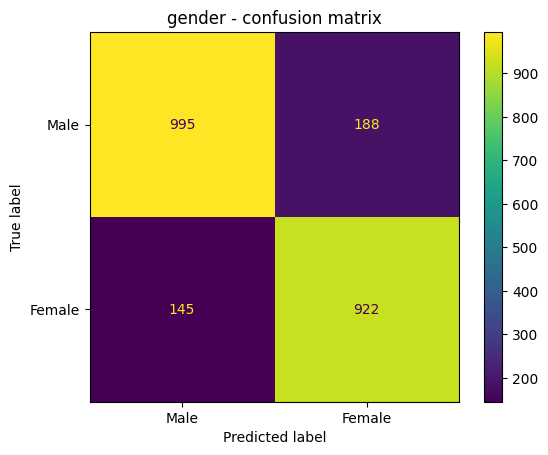

In [12]:
cm = confusion_matrix(gender_test, gender_pred)
ConfusionMatrixDisplay(cm, display_labels=["Male", "Female"]).plot()
plt.title("gender - confusion matrix")
plt.savefig(os.path.join(OUTPUT_DIR, "gender_confusion_matrix.png"))
plt.show()

## Step 5 - save the model

In [13]:
model.save(os.path.join(OUTPUT_DIR, "age_gender_cnn.keras"))
print("saved model + metrics + confusion matrix to", OUTPUT_DIR)

saved model + metrics + confusion matrix to /kaggle/working


## Step 6 - multi-person detection pipeline

In [14]:
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_default.xml")

def preprocess_face(gray_crop):
    face = cv2.resize(gray_crop, (IMG_SIZE, IMG_SIZE))
    face = cv2.equalizeHist(face)
    return face

def predict_face(face_gray):
    x = face_gray.astype("float32").reshape(1, IMG_SIZE, IMG_SIZE, 1) / 255.0
    gender_prob, age_val = model.predict(x, verbose=0)
    gender_label = "Female" if gender_prob[0][0] > 0.5 else "Male"
    age = float(np.clip(age_val[0][0], 0, 100))
    is_senior = age > SENIOR_AGE_THRESHOLD
    return age, gender_label, is_senior

In [15]:
MIN_OBSERVATIONS_TO_LOG = 4  # wait for this many hits on a track before logging it


def box_iou(box_a, box_b):
    ax, ay, aw, ah = box_a
    bx, by, bw, bh = box_b
    x1, y1 = max(ax, bx), max(ay, by)
    x2, y2 = min(ax + aw, bx + bw), min(ay + ah, by + bh)
    inter = max(0, x2 - x1) * max(0, y2 - y1)
    union = aw * ah + bw * bh - inter
    return inter / union if union > 0 else 0.0


class Track:
    def __init__(self, tid, box):
        self.id = tid
        self.box = box
        self.missed = 0
        self.logged = False
        self.age_samples = []
        self.gender_samples = []  # 0 = male, 1 = female

    def add_prediction(self, age, gender_label):
        self.age_samples.append(age)
        self.gender_samples.append(1 if gender_label == "Female" else 0)
        self.age_samples = self.age_samples[-10:]        # only need a recent window
        self.gender_samples = self.gender_samples[-10:]

    @property
    def stable_age(self):
        return sum(self.age_samples) / len(self.age_samples) if self.age_samples else None

    @property
    def stable_gender(self):
        if not self.gender_samples:
            return None
        # majority vote over the recent window
        return "Female" if sum(self.gender_samples) / len(self.gender_samples) > 0.5 else "Male"


class Tracker:
    def __init__(self, min_iou=0.15, max_missed=40):
        self.tracks = {}
        self.next_id = 1
        self.min_iou = min_iou
        self.max_missed = max_missed   # ~1.3s of missed frames at 30fps, so someone briefly
                                         # blocked by another shopper doesn't get logged twice

    def update(self, boxes):
        assigned = {}
        used_tracks = set()
        for box in boxes:
            best_id, best_iou = None, self.min_iou
            for tid, t in self.tracks.items():
                if tid in used_tracks:
                    continue
                score = box_iou(t.box, box)
                if score > best_iou:
                    best_id, best_iou = tid, score
            if best_id is None:
                best_id = self.next_id
                self.tracks[best_id] = Track(best_id, box)
                self.next_id += 1
            else:
                self.tracks[best_id].box = box
                self.tracks[best_id].missed = 0
            used_tracks.add(best_id)
            assigned[best_id] = box

        # age out tracks that vanished for too long
        for tid in list(self.tracks.keys()):
            if tid not in assigned:
                self.tracks[tid].missed += 1
                if self.tracks[tid].missed > self.max_missed:
                    del self.tracks[tid]

        return assigned

In [16]:
MIN_FACE_STD = 20  

def log_visit(age, gender, is_senior):
    row = pd.DataFrame([{
        "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "age": round(age, 1),
        "gender": gender,
        "senior_citizen": "Yes" if is_senior else "No",
    }])
    header = not os.path.exists(CSV_PATH)
    row.to_csv(CSV_PATH, mode="a", header=header, index=False)
    pd.read_csv(CSV_PATH).to_excel(XLSX_PATH, index=False, engine="openpyxl")

    global total_visits_logged
    total_visits_logged += 1


def process_frame(frame_bgr, tracker):
    gray_raw = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2GRAY)
    gray_eq = cv2.equalizeHist(gray_raw)

    
    raw_boxes = face_cascade.detectMultiScale(gray_eq, scaleFactor=1.1, minNeighbors=10, minSize=(80, 80))
    # drop any "face" that's basically a flat patch of pixels (wall, glare, signage) before
    # it ever reaches the tracker -- see MIN_FACE_STD note above
    boxes = [
        (x, y, w, h) for (x, y, w, h) in raw_boxes
        if gray_raw[y:y + h, x:x + w].std() >= MIN_FACE_STD
    ]

    assigned = tracker.update(boxes)

    annotated = frame_bgr.copy()
    for tid, (x, y, w, h) in assigned.items():
        face = preprocess_face(gray_eq[y:y + h, x:x + w])
        age, gender, is_senior = predict_face(face)

        track = tracker.tracks[tid]
        track.add_prediction(age, gender)

        display_age = track.stable_age if track.stable_age is not None else age
        display_gender = track.stable_gender if track.stable_gender is not None else gender
        display_senior = display_age > SENIOR_AGE_THRESHOLD

        color = (0, 0, 255) if display_senior else (0, 180, 0)
        cv2.rectangle(annotated, (x, y), (x + w, y + h), color, 2)
        cv2.putText(annotated, f"{display_gender} ~{display_age:.0f}y", (x, max(0, y - 8)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)
        if display_senior:
            cv2.putText(annotated, "SENIOR CITIZEN", (x, y + h + 20),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

        if not track.logged and len(track.age_samples) >= MIN_OBSERVATIONS_TO_LOG:
            log_visit(track.stable_age, track.stable_gender, track.stable_age > SENIOR_AGE_THRESHOLD)
            track.logged = True

    return annotated

## Step 7 - quick demo (no real video needed)

Kaggle can't hand us a real video file out of nowhere, so this just glues a few real face crops
from the dataset side by side into one "group photo" and runs the exact same pipeline on it -
proves the multi-face detection + CSV/Excel logging actually works end to end.

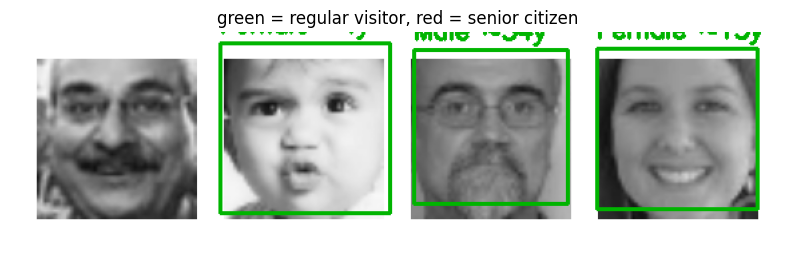

             timestamp   age  gender senior_citizen
0  2026-09-01 10:41:34  33.8    Male             No
1  2026-09-01 10:41:35  12.5  Female             No
2  2026-09-01 10:41:35   4.1  Female             No


In [17]:
demo_faces = [row_to_face(p) for p in work_df["pixels"].sample(4, random_state=3)]

face_size, pad = 120, 20
n = len(demo_faces)
canvas_w = n * face_size + (n + 1) * pad
canvas_h = face_size + 2 * pad
canvas = np.full((canvas_h, canvas_w, 3), 255, dtype=np.uint8)

for i, face in enumerate(demo_faces):
    face_big = cv2.resize(face, (face_size, face_size))
    x = pad + i * (face_size + pad)
    canvas[pad:pad + face_size, x:x + face_size] = cv2.cvtColor(face_big, cv2.COLOR_GRAY2BGR)

demo_tracker = Tracker()

for _ in range(8):
    annotated = process_frame(canvas, demo_tracker)

plt.figure(figsize=(10, 3))
plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title("green = regular visitor, red = senior citizen")
plt.show()

if os.path.exists(CSV_PATH):
    print(pd.read_csv(CSV_PATH))
else:
    print("nothing logged yet -- Haar cascade probably didn't lock onto a face in this synthetic "
          "collage for long enough. not a big deal, the webcam/video tabs further down are the "
          "real test anyway")

## Step 8 - GUI

Two tabs:
- **Live Webcam** - streams straight from your browser's camera (Gradio handles the camera
  permission popup client-side, so this works even though the notebook itself is running on
  Kaggle's servers, not your laptop)
- **Upload Video** - drop in a video file instead, it processes the whole thing and gives you back
  the log

Each tab gets its own tracker so a person walking past the webcam and a person in an uploaded video
don't get mixed up with each other.

In [18]:
webcam_tracker = Tracker()

def webcam_stream(frame):
    if frame is None:
        return None
    frame_bgr = cv2.cvtColor(frame, cv2.COLOR_RGB2BGR)
    annotated = process_frame(frame_bgr, webcam_tracker)
    return cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)

webcam_tab = gr.Interface(
    fn=webcam_stream,
    inputs=gr.Image(sources=["webcam"], streaming=True, label="Live feed"),
    outputs=gr.Image(label="Detections"),
    live=True,
)

In [19]:
def process_video(video_path):
    global total_visits_logged
    visits_before = total_visits_logged

    tracker = Tracker()
    cap = cv2.VideoCapture(video_path)
    last_frame = None
    frame_count = 0

    while True:
        ok, frame = cap.read()
        if not ok:
            break
        last_frame = process_frame(frame, tracker)
        frame_count += 1
    cap.release()

    new_visits = total_visits_logged - visits_before
    summary = f"processed {frame_count} frames, {new_visits} new visit(s) logged this run"
    last_frame_rgb = cv2.cvtColor(last_frame, cv2.COLOR_BGR2RGB) if last_frame is not None else None
    return last_frame_rgb, summary, CSV_PATH, XLSX_PATH

video_tab = gr.Interface(
    fn=process_video,
    inputs=gr.Video(label="Upload a video"),
    outputs=[
        gr.Image(label="Last annotated frame"),
        gr.Textbox(label="Summary"),
        gr.File(label="visit_log.csv"),
        gr.File(label="visit_log.xlsx"),
    ],
)

In [20]:
demo = gr.TabbedInterface(
    [webcam_tab, video_tab],
    ["Live Webcam", "Upload Video"],
    title="Senior Citizen Identification",
)

demo.launch()

* Running on local URL:  http://127.0.0.1:7860
It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

* Running on public URL: https://622f75499457d6c3d0.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## Insights

- The CNN predicts age and gender from facial images.
- People with predicted age above 60 are marked as **Senior Citizens**.
- The system can process multiple people from video or webcam input.
- Age, gender, and visit time can be stored in CSV/Excel format.
- The Gradio GUI makes the system easy to use and view predictions.

## Conclusion

The project successfully develops a CNN-based Senior Citizen Identification System. It predicts age and gender, identifies people above 60 as senior citizens, and records their age, gender, and visit time. The combination of CNN, computer vision, data logging, and GUI provides a practical solution for automated monitoring.

## Future Scope

- Train the model on a larger and more diverse dataset.
- Improve age prediction accuracy.
- Improve face detection in crowded scenes.
- Optimize real-time webcam performance.
- Add confidence scores for predictions.
- Add a dashboard for visitor statistics.
- Deploy the system using Streamlit or Flask.